# All About Cross-Validation in Machine Learning

---

## What is Cross-Validation and Why Does It Matter?

Imagine you're studying for an exam. If you only practice on the same 10 questions over and over, you might memorize the answers without truly understanding the material. On exam day, when you see new questions, you'll struggle — even though you "aced" the practice set.

Machine learning models face the exact same problem. If we train a model and evaluate it on the **same data it learned from**, we get a falsely optimistic score. The model has essentially "memorized" the data. This is called **overfitting**.

**Cross-validation** is the solution. It is a family of techniques that rigorously test how well a model generalizes to **new, unseen data** — giving us an honest picture of real-world performance.

---

## What We're Building in This Notebook

We'll explore **8 cross-validation techniques**, organized in two tiers:

| Tier | Technique | Purpose |
|------|-----------|--------|
| **Tier 1** | Train/Test Split | Baseline evaluation |
| **Tier 1** | K-Fold CV | Robust evaluation |
| **Tier 1** | Stratified K-Fold | Evaluation on imbalanced data |
| **Tier 1** | Time Series Split | Evaluation on temporal data |
| **Tier 2** | Grid Search CV | Exhaustive hyperparameter tuning |
| **Tier 2** | Random Search CV | Efficient hyperparameter tuning |
| **Tier 2** | Bayesian Opt. — scikit-optimize | Intelligent tuning via Gaussian Process |
| **Tier 2** | Bayesian Opt. — Optuna | Intelligent tuning via TPE (industry standard) |

## Dataset and model being used
**Dataset:** The [Diamonds dataset](https://ggplot2.tidyverse.org/reference/diamonds.html) from Seaborn — 53,940 diamonds with features like carat, cut, color, and clarity. We'll predict **price category** (Low, Mid, High, Premium).

**Model:** Random Forest Classifier — used consistently across all techniques so results are directly comparable.

---

## Cell 0 — Install Required Libraries

Two libraries are not part of the standard Python environment and must be installed before running this notebook:

- **`scikit-optimize`** — provides `BayesSearchCV`, a drop-in Bayesian replacement for `GridSearchCV` using a Gaussian Process surrogate model
- **`optuna`** — the industry-standard Bayesian optimization framework, using the TPE (Tree-structured Parzen Estimator) algorithm

Run this cell once. You do not need to re-run it after the packages are installed.

In [26]:
# Install required packages — run once
import sys
!{sys.executable} -m pip install scikit-optimize optuna --quiet
print('Installation complete.')

Installation complete.


## Cell 1 — Imports and Setup

We load all the libraries we need. Here's a quick breakdown:

- **seaborn / pandas / numpy** — data loading and manipulation
- **matplotlib** — plotting and visualization
- **sklearn** — all cross-validation tools and the Random Forest model
- **skopt** — scikit-optimize for Bayesian Search CV (Gaussian Process approach)
- **optuna** — Bayesian optimization via TPE (industry standard)
- **warnings** — we suppress minor warnings to keep the output clean

In [27]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    TimeSeriesSplit,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint

# scikit-optimize — Bayesian Search via Gaussian Process
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# Optuna — Bayesian optimization via TPE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Consistent plot style throughout the notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


## Cell 2 — Load and Prepare the Dataset

We load the **Diamonds dataset** directly from Seaborn — no file downloads needed.

### About the Dataset
The diamonds dataset contains **53,940 rows** and the following features:

| Feature | Description |
|---------|-------------|
| `carat` | Weight of the diamond |
| `cut` | Quality of the cut (Fair → Ideal) |
| `color` | Diamond color (D = best, J = worst) |
| `clarity` | How clear the diamond is |
| `depth` | Total depth percentage |
| `table` | Width of the top of the diamond |
| `x, y, z` | Physical dimensions in mm |
| `price` | Price in US dollars (**our target**) |

### What We're Predicting
Instead of predicting the exact dollar price (regression), we convert `price` into **4 categories** to make this a classification problem — which lets us demonstrate all CV techniques cleanly:

| Category | Price Range |
|----------|-------------|
| `Low` | < \$950 |
| `Mid` | \$950 – \$3,000 |
| `High` | \$3,000 – \$8,000 |
| `Premium` | > \$8,000 |

### How We Create These Categories — `pd.cut()`

`pd.cut()` divides a continuous numeric column into discrete bins (categories). Think of it like a grading scale — a student scores 85 and you call it a 'B'. `pd.cut()` does the same thing for any numeric data.

```python
bins   = [0, 950, 3000, 8000, df['price'].max() + 1]
labels = ['Low', 'Mid', 'High', 'Premium']
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)
```

It reads the boundary points left to right and assigns a label to each interval:

```
bins:   [0 ──── 950 ──── 3000 ──── 8000 ──── max]
labels:    'Low'    'Mid'    'High'   'Premium'
```

So a diamond priced at `$4,500` falls between `3000` and `8000` and gets the label `'High'`.

> **Why `df['price'].max() + 1`?** The last boundary must be *strictly greater than* the largest value in the data. Without the `+ 1`, the most expensive diamond would fall outside all bins and silently become `NaN`.

### Encoding Categorical Features — `LabelEncoder`

Machine learning models work with numbers, not text. So we convert categorical columns (`cut`, `color`, `clarity`) into numeric codes using **Label Encoding**.

For example, `cut` has values like `'Fair'`, `'Good'`, `'Very Good'`, `'Premium'`, `'Ideal'`. Label Encoding maps these to integers `0, 1, 2, 3, 4`. The model can now do math on them.

### Label Encoding vs One-Hot Encoding

Label Encoding assigns a single integer to each category, which implies an ordering — the model may interpret `4 > 3 > 2 > 1 > 0` as meaningful. **For tree-based models like Random Forest this is fine**, because trees split on thresholds and do not assume equal spacing between values.

**One-Hot Encoding** is the alternative. Instead of one column with integers, it creates a separate binary column for each category:

```
Label Encoding:           One-Hot Encoding:
cut                       cut_Fair  cut_Good  cut_Ideal  cut_Premium  cut_VeryGood
Fair      → 0            1         0         0          0            0
Good      → 1            0         1         0          0            0
Ideal     → 2     →      0         0         1          0            0
Premium   → 3            0         0         0          1            0
Very Good → 4            0         0         0          0            1
```

One-Hot Encoding has **no implied order**, so it is safer for linear models (Logistic Regression, SVM, Linear Regression). The trade-off is it creates many extra columns when a feature has many unique categories.

| | Label Encoding | One-Hot Encoding |
|---|---|---|
| Implies ordering? | Yes | No |
| Extra columns? | No | One per category |
| Use with trees? | Safe | Also works |
| Use with linear models? | Risky | Preferred |

Since we are using **Random Forest** throughout this notebook, Label Encoding is the appropriate choice.

In [28]:
# Load dataset
df = sns.load_dataset('diamonds')
print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (53940, 10)

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [29]:
# Create price category target variable
bins   = [0, 950, 3000, 8000, df['price'].max() + 1]
labels = ['Low', 'Mid', 'High', 'Premium']
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)

# Encode categorical features
le = LabelEncoder()
for col in ['cut', 'color', 'clarity']:
    df[col] = le.fit_transform(df[col])

# Encode target
df['price_label'] = le.fit_transform(df['price_category'])

# Define features and target
FEATURES = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
TARGET   = 'price_label'

X = df[FEATURES]
y = df[TARGET]

print(f'Features : {FEATURES}')
print(f'Target   : {TARGET}')
print(f'\nClass distribution:')
print(df['price_category'].value_counts().sort_index())

Features : ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
Target   : price_label

Class distribution:
price_category
Low        13490
Mid        16846
High       15999
Premium     7605
Name: count, dtype: int64


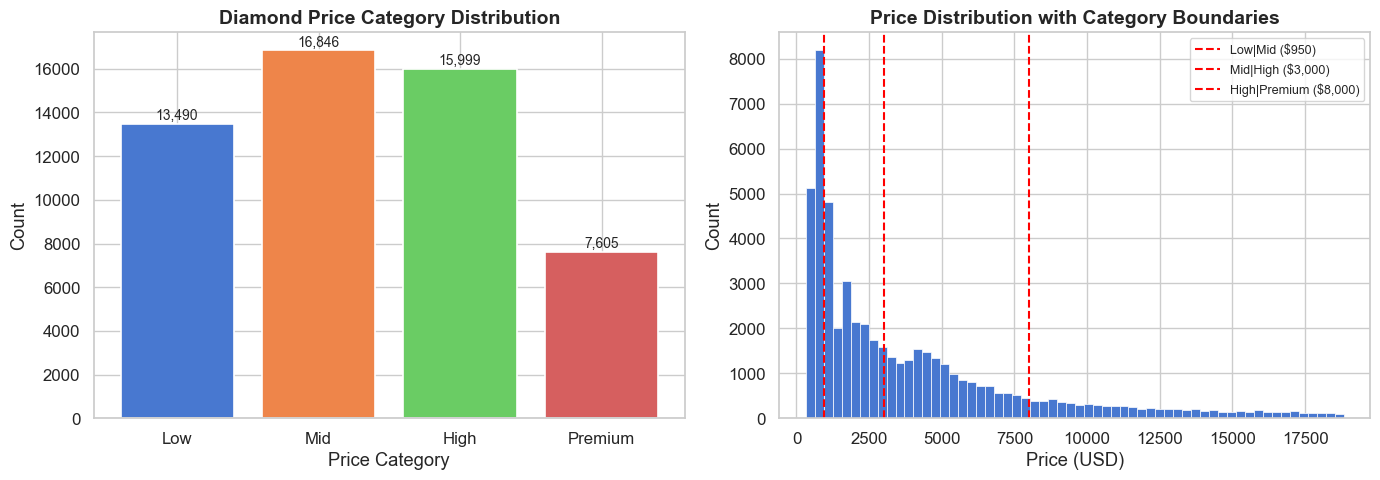

In [30]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['price_category'].value_counts().reindex(labels)
axes[0].bar(counts.index, counts.values,
            color=sns.color_palette('muted', 4), edgecolor='white', linewidth=1.2)
axes[0].set_title('Diamond Price Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Price histogram
axes[1].hist(df['price'], bins=60, color=sns.color_palette('muted')[0],
             edgecolor='white', linewidth=0.5)
for boundary, lbl in zip(bins[1:-1], ['Low|Mid', 'Mid|High', 'High|Premium']):
    axes[1].axvline(boundary, color='red', linestyle='--', linewidth=1.5, label=f'{lbl} (${boundary:,})')
axes[1].set_title('Price Distribution with Category Boundaries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Reading These Charts

**Left chart — Category Distribution:**
Shows how many diamonds fall into each price category. Notice that the dataset is **not perfectly balanced** — `Mid` has the most samples (~16,800) and `Premium` the fewest (~7,600). This imbalance is exactly why Stratified K-Fold (Section 3) matters.

**Right chart — Price Histogram with Boundaries:**
Shows the raw price distribution before binning. The dashed red lines mark the three cut points where we draw the category boundaries. Notice how most diamonds cluster at the lower end (the distribution is right-skewed), which is why the `Low` and `Mid` bins are narrow in dollar terms but still capture many samples.

---
# TIER 1 — Validation Fundamentals
---

## Section 1 — Train/Test Split

### The Concept
The train/test split is the **simplest and most fundamental** validation technique. The idea is straightforward:

1. Take your full dataset
2. Randomly divide it into two groups: a **training set** and a **test set**
3. The model learns *only* from the training set
4. We evaluate performance *only* on the test set

This way, we simulate what happens in the real world — the model is scored on data it has **never seen before**.

### The Typical Split
A common ratio is **80% train / 20% test**, though 70/30 is also widely used. The right split depends on how much data you have.

### The Problem with This Approach
The result depends heavily on **which samples happen to land in the test set**. You might get lucky (test set is easy) or unlucky (test set is hard). With a single split, you can't distinguish skill from luck.

**This is exactly why more advanced CV methods exist.** But the train/test split is always your starting point — it's fast, simple, and gives you a quick sanity check.

### Key Parameter: `random_state`
Setting `random_state=42` (or any integer) makes the split **reproducible** — you and your colleagues get the same split every time. Without it, results change on every run.

In [31]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Total samples  : {len(X):,}')
print(f'Training set   : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test set       : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

# Train and evaluate
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

tt_accuracy = accuracy_score(y_test, y_pred)
print(f'\nTest Accuracy  : {tt_accuracy:.4f} ({tt_accuracy*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=labels))

Total samples  : 53,940
Training set   : 43,152 (80.0%)
Test set       : 10,788  (20.0%)

Test Accuracy  : 0.9481 (94.81%)

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.94      0.94      3213
         Mid       0.96      0.97      0.96      2786
        High       0.94      0.93      0.94      3282
     Premium       0.95      0.95      0.95      1507

    accuracy                           0.95     10788
   macro avg       0.95      0.95      0.95     10788
weighted avg       0.95      0.95      0.95     10788



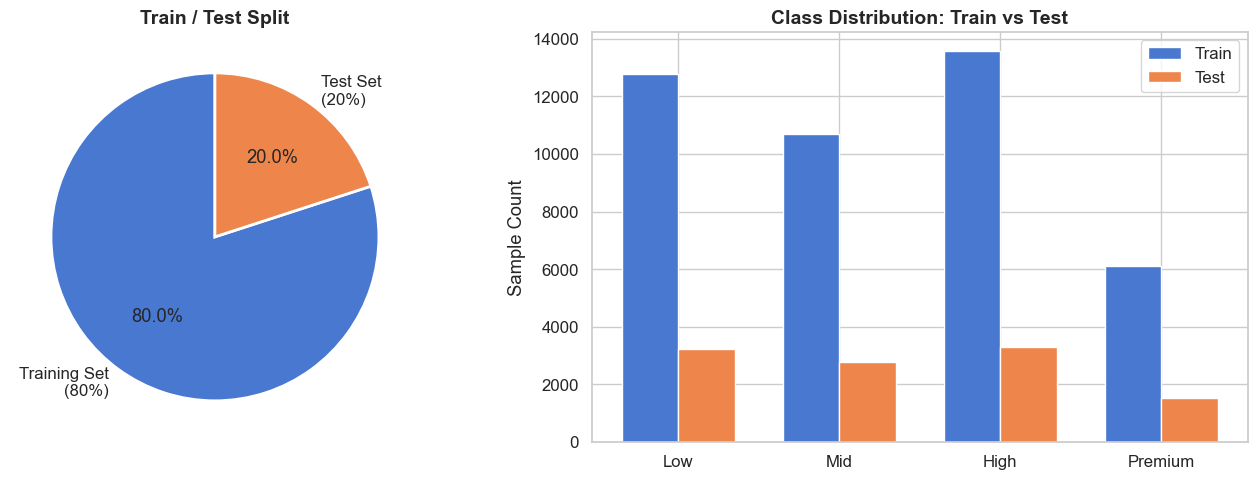

Train/Test Split Accuracy: 94.81%


In [32]:
# Visualize the split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of split
axes[0].pie(
    [len(X_train), len(X_test)],
    labels=['Training Set\n(80%)', 'Test Set\n(20%)'],
    colors=sns.color_palette('muted', 2),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Train / Test Split', fontsize=14, fontweight='bold')

# Class distribution in train vs test
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist  = pd.Series(y_test).value_counts().sort_index()
x_pos = np.arange(len(labels))
width = 0.35
axes[1].bar(x_pos - width/2, train_dist.values, width, label='Train', color=sns.color_palette('muted')[0])
axes[1].bar(x_pos + width/2, test_dist.values,  width, label='Test',  color=sns.color_palette('muted')[1])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title('Class Distribution: Train vs Test', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sample Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Train/Test Split Accuracy: {tt_accuracy*100:.2f}%')

### Reading These Charts

**Left chart — Pie Chart:**
A simple visual confirming the 80/20 split. Nothing surprising here — this is just to make the concept tangible.

**Right chart — Class Distribution in Train vs Test:**
This is the more important chart. It shows how many samples of each price category ended up in the training set versus the test set. Ideally these bars should be proportional — if the train bar for `Premium` is much taller relative to the test bar compared to other categories, the split is unbalanced. A clean proportional split means the test set is a fair representative sample of the training data.

---
## Section 2 — K-Fold Cross-Validation

### The Problem with a Single Split
With a single train/test split, we only evaluate the model once. The score we get could be **higher or lower than reality** purely due to chance — depending on which samples ended up in the test set.

### The K-Fold Solution
K-Fold fixes this by evaluating the model **K times**, each time on a different portion of the data:

1. Divide the dataset into **K equal-sized folds** (K=5 in the diagram below)
2. In round 1: train on folds 2-5, test on fold 1
3. In round 2: train on folds 1, 3-5, test on fold 2
4. ... and so on until every fold has been used as the test set exactly once
5. **Final score = average of all K scores**

```
Fold 1:  [TEST ] [TRAIN] [TRAIN] [TRAIN] [TRAIN]  → Score 1
Fold 2:  [TRAIN] [TEST ] [TRAIN] [TRAIN] [TRAIN]  → Score 2
Fold 3:  [TRAIN] [TRAIN] [TEST ] [TRAIN] [TRAIN]  → Score 3
Fold 4:  [TRAIN] [TRAIN] [TRAIN] [TEST ] [TRAIN]  → Score 4
Fold 5:  [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST ]  → Score 5
                                               ↓
                                    Final = mean(Score 1..5)
```

### Why This is Better
- **Every sample** gets used for both training and testing
- **The average** is a much more reliable estimate than a single score
- **The standard deviation** across folds tells you how stable the model is

### Choosing K
- **K=5** is the most common default — good balance of speed and reliability
- **K=10** gives slightly better estimates but takes twice as long
- Avoid K=2 (too high variance) or K=N (too slow — that's LOOCV)

In [33]:
# ── K-Fold Cross-Validation ───────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_kfold = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

kfold_scores = cross_val_score(rf_kfold, X, y, cv=kf, scoring='accuracy', n_jobs=-1)

print('K-Fold Cross-Validation Results (K=5)')
print('=' * 40)
for i, score in enumerate(kfold_scores, 1):
    print(f'  Fold {i}: {score:.4f} ({score*100:.2f}%)')
print('─' * 40)
print(f'  Mean  : {kfold_scores.mean():.4f} ({kfold_scores.mean()*100:.2f}%)')
print(f'  Std   : {kfold_scores.std():.4f} ({kfold_scores.std()*100:.2f}%)')
print(f'  95% CI: [{(kfold_scores.mean() - 2*kfold_scores.std())*100:.2f}% – {(kfold_scores.mean() + 2*kfold_scores.std())*100:.2f}%]')

K-Fold Cross-Validation Results (K=5)
  Fold 1: 0.9473 (94.73%)
  Fold 2: 0.9416 (94.16%)
  Fold 3: 0.9444 (94.44%)
  Fold 4: 0.9414 (94.14%)
  Fold 5: 0.9482 (94.82%)
────────────────────────────────────────
  Mean  : 0.9446 (94.46%)
  Std   : 0.0028 (0.28%)
  95% CI: [93.90% – 95.02%]


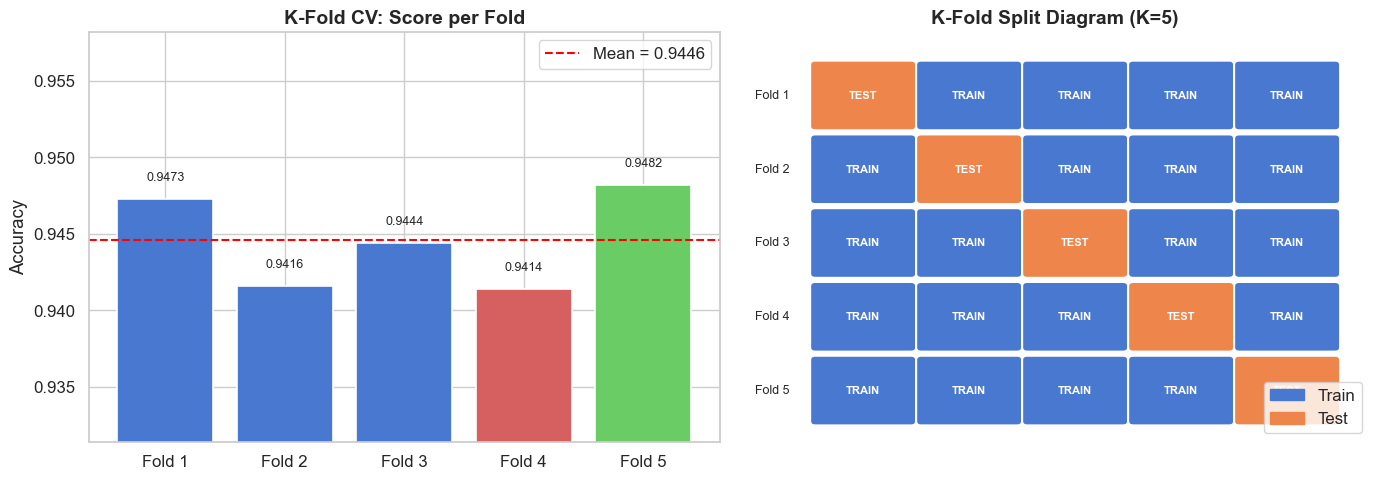

K-Fold CV Mean Accuracy: 94.46% ± 0.28%


In [34]:
# Visualize K-Fold results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of fold scores
fold_labels = [f'Fold {i}' for i in range(1, 6)]
colors = [sns.color_palette('muted')[2] if s == kfold_scores.max()
          else (sns.color_palette('muted')[3] if s == kfold_scores.min()
          else sns.color_palette('muted')[0]) for s in kfold_scores]
bars = axes[0].bar(fold_labels, kfold_scores, color=colors, edgecolor='white', linewidth=1.2)
axes[0].axhline(kfold_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {kfold_scores.mean():.4f}')
axes[0].set_ylim(kfold_scores.min() - 0.01, kfold_scores.max() + 0.01)
axes[0].set_title('K-Fold CV: Score per Fold', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
for bar, score in zip(bars, kfold_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}', ha='center', va='bottom', fontsize=9)

# Visual fold diagram
n_splits = 5
for fold_idx in range(n_splits):
    for block in range(n_splits):
        color = sns.color_palette('muted')[1] if block == fold_idx else sns.color_palette('muted')[0]
        rect = mpatches.FancyBboxPatch(
            (block * 0.21, (n_splits - fold_idx - 1) * 0.18),
            0.19, 0.15,
            boxstyle='round,pad=0.01',
            linewidth=1.5, edgecolor='white', facecolor=color
        )
        axes[1].add_patch(rect)
        label = 'TEST' if block == fold_idx else 'TRAIN'
        axes[1].text(block * 0.21 + 0.095, (n_splits - fold_idx - 1) * 0.18 + 0.075,
                     label, ha='center', va='center', fontsize=8,
                     color='white', fontweight='bold')
    axes[1].text(-0.05, (n_splits - fold_idx - 1) * 0.18 + 0.075,
                 f'Fold {fold_idx+1}', ha='right', va='center', fontsize=9)
axes[1].set_xlim(-0.15, 1.1)
axes[1].set_ylim(-0.05, 0.95)
axes[1].axis('off')
axes[1].set_title('K-Fold Split Diagram (K=5)', fontsize=14, fontweight='bold')
train_patch = mpatches.Patch(color=sns.color_palette('muted')[0], label='Train')
test_patch  = mpatches.Patch(color=sns.color_palette('muted')[1], label='Test')
axes[1].legend(handles=[train_patch, test_patch], loc='lower right')

plt.tight_layout()
plt.show()
print(f'K-Fold CV Mean Accuracy: {kfold_scores.mean()*100:.2f}% ± {kfold_scores.std()*100:.2f}%')

### Reading These Charts

**Left chart — Score per Fold:**
Each bar is the accuracy for one fold. The **red dashed line** is the mean across all folds — this is our final reported score. The highlighted bars show the highest (green) and lowest (red) performing folds. A small gap between highest and lowest means the model is stable; a large gap means it is sensitive to which data it trains on.

**Right chart — Split Diagram:**
A visual of how K-Fold works. Each row is one fold. The orange block is the test set for that round — it moves along one position each time. Every sample gets to be in the test set exactly once across all 5 folds.

---
## Section 3 — Stratified K-Fold Cross-Validation

### The Problem with Standard K-Fold
Standard K-Fold splits the data **randomly**, without paying attention to class distribution. This creates a silent problem with **imbalanced datasets**.

Imagine your dataset has 90% "No" and 10% "Yes" samples. With a random split, one fold might accidentally contain almost no "Yes" samples. The model never learns about that class in that round — and the evaluation is meaningless.

### The Stratified Fix
Stratified K-Fold adds one guarantee: **each fold preserves the same class proportions as the full dataset**.

If the full dataset is 60% Low, 25% Mid, 10% High, 5% Premium — then every single fold will also be approximately 60% Low, 25% Mid, 10% High, 5% Premium.

```
Original:   [60% Low | 25% Mid | 10% High | 5% Premium]
              ↓ Each fold mirrors this proportion ↓
Fold 1 TEST: [60% Low | 25% Mid | 10% High | 5% Premium]
Fold 2 TEST: [60% Low | 25% Mid | 10% High | 5% Premium]
...and so on
```

### When to Use It
- **Always** use Stratified K-Fold for **classification** problems
- It is the default in `sklearn` when you call `cross_val_score` with a classifier
- Especially important for imbalanced datasets, but good practice regardless

### Our Dataset
Our diamond price categories are not perfectly balanced (Low has the fewest samples, Mid has the most). Stratification ensures every fold has a representative mix.

In [35]:
# ── Stratified K-Fold ─────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_skfold = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

skfold_scores = cross_val_score(rf_skfold, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print('Stratified K-Fold Cross-Validation Results (K=5)')
print('=' * 50)
for i, score in enumerate(skfold_scores, 1):
    print(f'  Fold {i}: {score:.4f} ({score*100:.2f}%)')
print('─' * 50)
print(f'  Mean  : {skfold_scores.mean():.4f} ({skfold_scores.mean()*100:.2f}%)')
print(f'  Std   : {skfold_scores.std():.4f} ({skfold_scores.std()*100:.2f}%)')

print('\n── Comparison with Standard K-Fold ──')
print(f'  K-Fold     Mean: {kfold_scores.mean():.4f}  Std: {kfold_scores.std():.4f}')
print(f'  Stratified Mean: {skfold_scores.mean():.4f}  Std: {skfold_scores.std():.4f}')

Stratified K-Fold Cross-Validation Results (K=5)
  Fold 1: 0.9447 (94.47%)
  Fold 2: 0.9498 (94.98%)
  Fold 3: 0.9444 (94.44%)
  Fold 4: 0.9429 (94.29%)
  Fold 5: 0.9434 (94.34%)
──────────────────────────────────────────────────
  Mean  : 0.9450 (94.50%)
  Std   : 0.0025 (0.25%)

── Comparison with Standard K-Fold ──
  K-Fold     Mean: 0.9446  Std: 0.0028
  Stratified Mean: 0.9450  Std: 0.0025


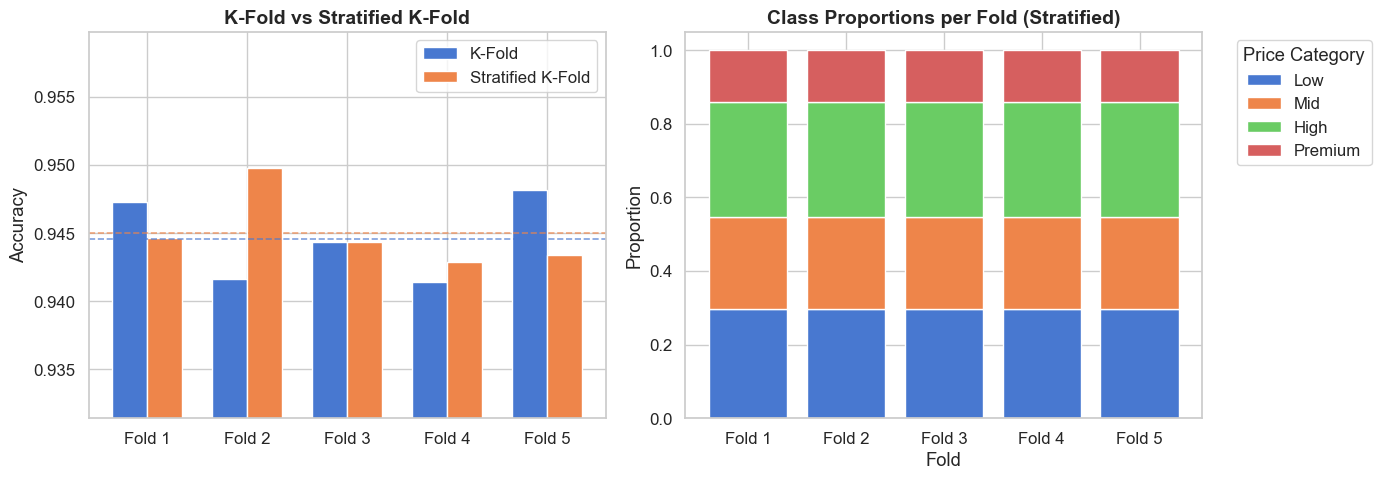

In [36]:
# Visualize class proportions per fold to confirm stratification
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare K-Fold vs Stratified K-Fold scores
x_pos = np.arange(5)
width = 0.35
axes[0].bar(x_pos - width/2, kfold_scores,  width, label='K-Fold',            color=sns.color_palette('muted')[0])
axes[0].bar(x_pos + width/2, skfold_scores, width, label='Stratified K-Fold', color=sns.color_palette('muted')[1])
axes[0].axhline(kfold_scores.mean(),  color=sns.color_palette('muted')[0], linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].axhline(skfold_scores.mean(), color=sns.color_palette('muted')[1], linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Fold {i}' for i in range(1, 6)])
axes[0].set_title('K-Fold vs Stratified K-Fold', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(min(kfold_scores.min(), skfold_scores.min()) - 0.01,
                 max(kfold_scores.max(), skfold_scores.max()) + 0.01)

# Class proportions per fold
fold_proportions = []
for _, test_idx in skf.split(X, y):
    fold_y = y.iloc[test_idx]
    props  = fold_y.value_counts(normalize=True).sort_index()
    fold_proportions.append(props.values)

fold_proportions = np.array(fold_proportions)
bottom = np.zeros(5)
palette = sns.color_palette('muted', 4)
for cls_idx, cls_label in enumerate(labels):
    axes[1].bar(range(1, 6), fold_proportions[:, cls_idx], bottom=bottom,
                label=cls_label, color=palette[cls_idx])
    bottom += fold_proportions[:, cls_idx]
axes[1].set_title('Class Proportions per Fold (Stratified)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticks(range(1, 6))
axes[1].set_xticklabels([f'Fold {i}' for i in range(1, 6)])
axes[1].legend(title='Price Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Reading These Charts

**Left chart — K-Fold vs Stratified K-Fold per Fold:**
Side-by-side bars for each fold let you directly compare the two methods. The dashed lines show each method's mean. If the Stratified bars are more consistent across folds (less spread), that confirms stratification is helping produce more stable estimates.

**Right chart — Class Proportions per Fold:**
This is the key proof that stratification is working. Each stacked bar represents one test fold, and the coloured segments show what fraction of that fold belongs to each price category. If stratification is working correctly, **all 5 bars should look nearly identical** — the same proportions of Low, Mid, High, and Premium in every fold. If they looked very different, it would mean some folds are easier or harder than others.

---
## Section 4 — Time Series Split

### Why Time Series Data is Different
All the techniques so far assume data points are **independent** — shuffling them around doesn't break anything. But time series data violates this assumption fundamentally.

Consider predicting stock prices. If your test set contains data from January and your training set contains data from February (the future), your model is essentially **cheating** — it's been trained on information that wouldn't have been available at prediction time. This is called **data leakage**, and it produces results that look great in testing but fail in production.

### The Time Series Split Rule
**Training data must always come before test data in time.** There is no exception.

```
Split 1:  [TRAIN──────] [TEST─]
Split 2:  [TRAIN───────────] [TEST─]
Split 3:  [TRAIN────────────────] [TEST─]
Split 4:  [TRAIN─────────────────────] [TEST─]
Split 5:  [TRAIN──────────────────────────] [TEST─]
           ───────── Time flows forward ─────────►
```

The training window **expands** as we move forward. The test set is always the next unseen chunk.

### Our Adaptation
The diamonds dataset doesn't have a real timestamp, so we **simulate temporal ordering** by sorting the data by `price` — treating cheap diamonds as "early" observations and expensive ones as "later". This is a common practice when demonstrating the concept on non-temporal datasets.

### Key Difference from K-Fold
- K-Fold: shuffles data, any fold can be test set
- Time Series Split: **no shuffling**, test is always the future, training always grows forward

### Understanding the Code

```python
df_ts = df.sort_values('price').reset_index(drop=True)
```
We sort the full dataset by `price` to simulate a time ordering — cheaper diamonds are treated as earlier observations, expensive ones as later. `reset_index(drop=True)` resets the row numbers to 0, 1, 2, ... after sorting so the index is clean.

```python
tss = TimeSeriesSplit(n_splits=5)
```
Creates 5 splits. Unlike `KFold`, this never shuffles the data — it always moves forward.

```python
for fold, (train_idx, test_idx) in enumerate(tss.split(X_ts), 1):
    X_tr, X_te = X_ts.iloc[train_idx], X_ts.iloc[test_idx]
    y_tr, y_te = y_ts.iloc[train_idx], y_ts.iloc[test_idx]
    rf_ts.fit(X_tr, y_tr)
    score = accuracy_score(y_te, rf_ts.predict(X_te))
```
`tss.split(X_ts)` yields pairs of `(train_idx, test_idx)` — integer positions telling us which rows belong to train and which to test for each fold. We use `.iloc[]` (positional indexing) to slice the data, then train and score as normal.

Notice we do **not** use `cross_val_score` here — that helper shuffles data internally, which would break the time-order guarantee. We loop manually to preserve the order.

In [ ]:
# ── Time Series Split ─────────────────────────────────────────────────────────
# Simulate temporal order by sorting on price (cheap → expensive)
df_ts = df.sort_values('price').reset_index(drop=True)
X_ts  = df_ts[FEATURES]
y_ts  = df_ts[TARGET]

tss = TimeSeriesSplit(n_splits=5)
rf_ts = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

ts_scores   = []
train_sizes = []
test_sizes  = []

for fold, (train_idx, test_idx) in enumerate(tss.split(X_ts), 1):
    X_tr, X_te = X_ts.iloc[train_idx], X_ts.iloc[test_idx]
    y_tr, y_te = y_ts.iloc[train_idx], y_ts.iloc[test_idx]
    rf_ts.fit(X_tr, y_tr)
    score = accuracy_score(y_te, rf_ts.predict(X_te))
    ts_scores.append(score)
    train_sizes.append(len(train_idx))
    test_sizes.append(len(test_idx))
    print(f'  Fold {fold}: Train={len(train_idx):,}  Test={len(test_idx):,}  Accuracy={score:.4f}')

ts_scores = np.array(ts_scores)
print('─' * 55)
print(f'  Mean  : {ts_scores.mean():.4f} ({ts_scores.mean()*100:.2f}%)')
print(f'  Std   : {ts_scores.std():.4f} ({ts_scores.std()*100:.2f}%)')

  Fold 1: Train=8,990  Test=8,990  Accuracy=0.5006
  Fold 2: Train=17,980  Test=8,990  Accuracy=0.9969
  Fold 3: Train=26,970  Test=8,990  Accuracy=0.3744
  Fold 4: Train=35,960  Test=8,990  Accuracy=0.9990
  Fold 5: Train=44,950  Test=8,990  Accuracy=0.1541
───────────────────────────────────────────────────────
  Mean  : 0.6050 (60.50%)
  Std   : 0.3395 (33.95%)


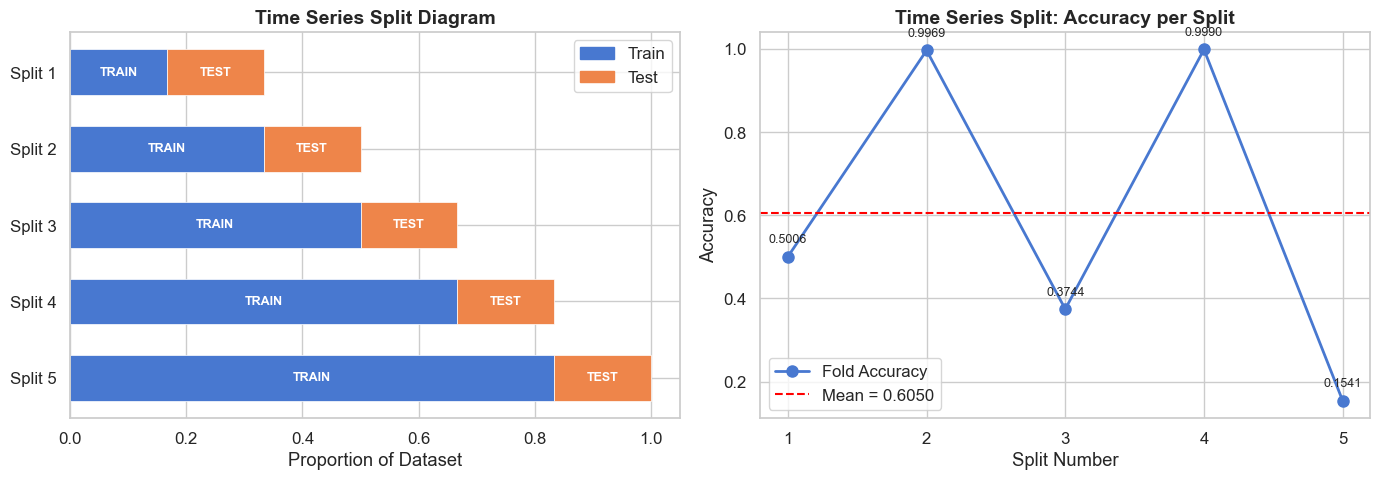

Time Series Split Mean Accuracy: 60.50% ± 33.95%


In [38]:
# Visualize Time Series Split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split diagram
total = len(X_ts)
palette_ts = sns.color_palette('muted', 2)
for fold_idx, (train_idx, test_idx) in enumerate(tss.split(X_ts)):
    y_pos = 4 - fold_idx
    axes[0].barh(y_pos, len(train_idx)/total, left=0,
                 color=palette_ts[0], edgecolor='white', linewidth=0.5, height=0.6)
    axes[0].barh(y_pos, len(test_idx)/total, left=len(train_idx)/total,
                 color=palette_ts[1], edgecolor='white', linewidth=0.5, height=0.6)
    axes[0].text(len(train_idx)/total / 2, y_pos, 'TRAIN',
                 ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    axes[0].text(len(train_idx)/total + len(test_idx)/total / 2, y_pos, 'TEST',
                 ha='center', va='center', color='white', fontsize=9, fontweight='bold')

axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Split {i}' for i in range(5, 0, -1)])
axes[0].set_xlabel('Proportion of Dataset')
axes[0].set_title('Time Series Split Diagram', fontsize=14, fontweight='bold')
train_patch = mpatches.Patch(color=palette_ts[0], label='Train')
test_patch  = mpatches.Patch(color=palette_ts[1], label='Test')
axes[0].legend(handles=[train_patch, test_patch])

# Scores per split
axes[1].plot(range(1, 6), ts_scores, marker='o', linewidth=2,
             color=sns.color_palette('muted')[0], markersize=8, label='Fold Accuracy')
axes[1].axhline(ts_scores.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {ts_scores.mean():.4f}')
for i, score in enumerate(ts_scores, 1):
    axes[1].annotate(f'{score:.4f}', (i, score),
                     textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
axes[1].set_title('Time Series Split: Accuracy per Split', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Split Number')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Time Series Split Mean Accuracy: {ts_scores.mean()*100:.2f}% ± {ts_scores.std()*100:.2f}%')

### Reading These Charts

**Left chart — Split Diagram:**
Each horizontal bar is one split. The left (blue) portion is the training window and the right (orange) portion is the test set. Notice how the training window **grows** with each split — Split 1 trains on the earliest ~17% of the data, Split 5 trains on ~83%. The test window stays the same size throughout.

**Right chart — Accuracy per Split:**
The accuracy line shows how the model performs as it trains on progressively more data. In a real time series, you would expect accuracy to generally improve as the training set grows (more history to learn from). Large swings in accuracy between splits — as you may see here since we are simulating time order with `price` — suggest that the model struggles when the test data looks very different from the training data, which is exactly what happens in real temporal problems.

---
# TIER 2 — Hyperparameter Tuning with Cross-Validation
---

### What Are Hyperparameters?

Machine learning models have two types of parameters:

- **Model parameters** — learned automatically from data (e.g., the weights in a neural network, the split thresholds in a decision tree). You don't set these — the training process finds them.

- **Hyperparameters** — settings you choose *before* training that control *how* the model learns (e.g., how many trees in a forest, how deep each tree can grow). These are not learned from data — **you must tune them**.

### Why Does Tuning Matter?
The default hyperparameters in sklearn are reasonable starting points, but they're rarely optimal for your specific dataset. Proper tuning can meaningfully improve performance.

### The Hyperparameters We'll Tune (Random Forest)

| Hyperparameter | What It Controls | Range We'll Search |
|----------------|-----------------|--------------------|
| `n_estimators` | Number of trees in the forest | 50 – 300 |
| `max_depth` | Maximum depth of each tree | 5 – 30 |
| `min_samples_split` | Min samples needed to split a node | 2 – 20 |
| `min_samples_leaf` | Min samples required at a leaf node | 1 – 10 |
| `max_features` | Features considered at each split | 'sqrt', 'log2' |

### Data Sample for Tuning
All four tuning methods below use a **30% stratified sample** of the full dataset. This keeps runtimes manageable while still being a fair comparison — all four methods use the exact same data.

In [39]:
# Shared sample for all four tuning methods — ensures a fair comparison
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.3, random_state=RANDOM_STATE, stratify=y
)
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Tuning sample: {len(X_sample):,} rows ({len(X_sample)/len(X)*100:.0f}% of full dataset)')
print(f'Inner CV     : StratifiedKFold, K=5')

Tuning sample: 16,182 rows (30% of full dataset)
Inner CV     : StratifiedKFold, K=5


---
## Section 5 — Grid Search CV

### The Concept
Grid Search is the most straightforward approach to hyperparameter tuning: you define a **grid** of all possible values you want to try, and it **tries every single combination**.

If you have:
- `n_estimators`: [100, 200]
- `max_depth`: [10, 20, 30]
- `min_samples_split`: [2, 5]

Grid Search will try **2 × 3 × 2 = 12 combinations**, training and evaluating the model for each one using K-Fold CV.

### The Process
```
For each combination of hyperparameters:
    Run 5-Fold CV on the training data
    Record the mean CV score
Pick the combination with the best mean CV score
Refit the model on all training data using those best params
```

### The Trade-off
- **Pro:** Guaranteed to find the best combination *within your defined grid*
- **Con:** Exponential blowup — adding one more parameter with 3 values triples the search time. A grid with 5 parameters and 4 values each = 4⁵ = **1,024 combinations** (× 5 folds = 5,120 training runs)

### When to Use Grid Search
- When you have **few hyperparameters** (1–3)
- When you have strong prior knowledge about reasonable value ranges
- When compute cost is low and you want exhaustive coverage

In [40]:
# ── Grid Search CV ────────────────────────────────────────────────────────────
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2']
}

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)
print(f'Total combinations: {total_combinations} × 5 folds = {total_combinations*5} model fits')

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid = param_grid,
    cv         = cv_tune,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

start = time.time()
grid_search.fit(X_sample, y_sample)
grid_time = time.time() - start

print(f'\nCompleted in      : {grid_time:.1f} seconds')
print(f'Best CV Accuracy  : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)')
print(f'Best Parameters   : {grid_search.best_params_}')

Total combinations: 54 × 5 folds = 270 model fits
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Completed in      : 38.6 seconds
Best CV Accuracy  : 0.9308 (93.08%)
Best Parameters   : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}


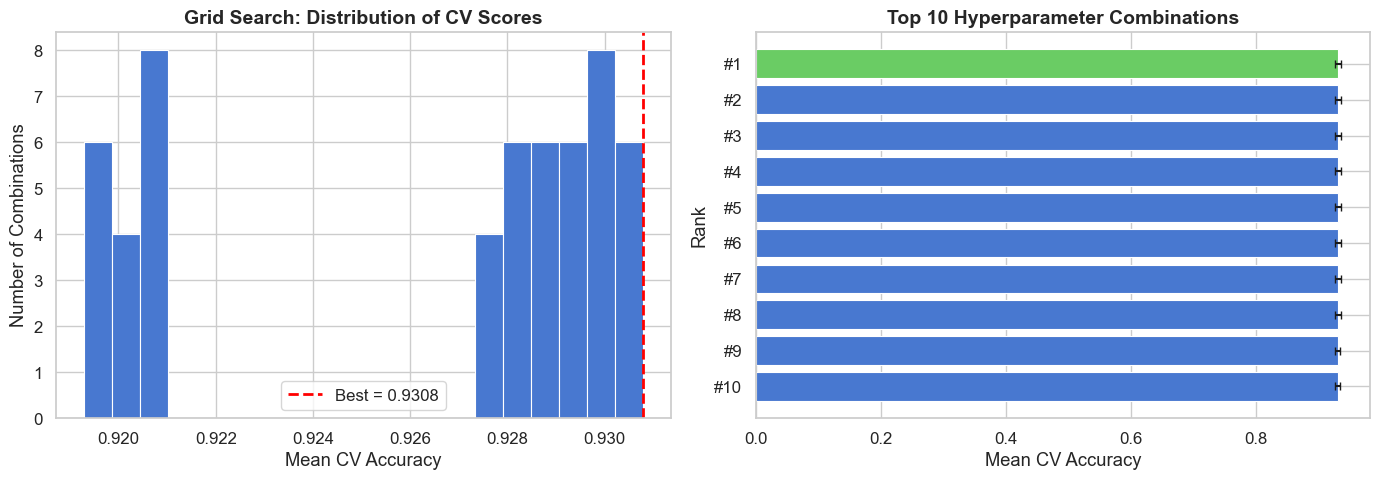

Grid Search  →  Best: 93.08%  |  Time: 38.6s  |  Fits: 270


In [41]:
# Visualize Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of all CV scores
axes[0].hist(grid_results['mean_test_score'], bins=20,
             color=sns.color_palette('muted')[0], edgecolor='white', linewidth=0.8)
axes[0].axvline(grid_search.best_score_, color='red', linestyle='--', linewidth=2,
                label=f'Best = {grid_search.best_score_:.4f}')
axes[0].set_title('Grid Search: Distribution of CV Scores', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mean CV Accuracy')
axes[0].set_ylabel('Number of Combinations')
axes[0].legend()

# Top 10 combinations
top10 = grid_results.nlargest(10, 'mean_test_score')[['mean_test_score', 'std_test_score']].reset_index(drop=True)
axes[1].barh(range(10, 0, -1), top10['mean_test_score'],
             xerr=top10['std_test_score'],
             color=[sns.color_palette('muted')[2] if i == 0
                    else sns.color_palette('muted')[0] for i in range(10)],
             edgecolor='white', linewidth=0.8, capsize=3)
axes[1].set_title('Top 10 Hyperparameter Combinations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean CV Accuracy')
axes[1].set_ylabel('Rank')
axes[1].set_yticks(range(1, 11))
axes[1].set_yticklabels([f'#{i}' for i in range(10, 0, -1)])

plt.tight_layout()
plt.show()
print(f'Grid Search  →  Best: {grid_search.best_score_*100:.2f}%  |  Time: {grid_time:.1f}s  |  Fits: {total_combinations*5}')

### Reading These Charts

**Left chart — Distribution of CV Scores:**
Each bar represents how many hyperparameter combinations achieved a given mean accuracy. The **red dashed line** marks the best combination found. A tight cluster near the right means most combinations performed similarly well — the model is not very sensitive to hyperparameters. A wide spread means some choices matter a lot.

**Right chart — Top 10 Combinations:**
The best 10 combinations ranked by accuracy. The **error bars** show the standard deviation across the 5 folds for each combination — a shorter error bar means that combination performed consistently across all folds. Ideally you want both high accuracy *and* small error bars (stability).

---
## Section 6 — Random Search CV

### The Problem with Grid Search
Grid Search explores the hyperparameter space **exhaustively but inefficiently**. In a grid, you're testing every combination — including many that are unlikely to be good. As the number of hyperparameters grows, the search space explodes exponentially.

### The Random Search Insight
In 2012, Bergstra & Bengio showed that **randomly sampling from the hyperparameter space** finds good solutions faster than exhaustive grid search. Why?

Because not all hyperparameters matter equally. If `n_estimators` has little effect on performance but `max_depth` matters a lot, a grid search wastes most of its budget testing different `n_estimators` values. Random search, by contrast, tries many different `max_depth` values with the same budget.

```
Grid Search (3×3 grid = 9 evaluations):
  n_estimators: [100, 100, 100, 200, 200, 200, 300, 300, 300]  ← only 3 unique
  max_depth:    [10,  20,  30,  10,  20,  30,  10,  20,  30]  ← only 3 unique

Random Search (9 evaluations from continuous distributions):
  n_estimators: [127, 243, 88, 301, 156, 72, 198, 265, 134]   ← 9 unique
  max_depth:    [7,   23,  15, 11,  28,  19, 4,   17,  31]    ← 9 unique
```

Random search explores the space **more broadly** with the same number of evaluations.

### Key Advantage
You control the **budget** via `n_iter`. You can do `n_iter=10` for a quick search or `n_iter=200` for a thorough one — Grid Search gives you no such control.

### When to Use Random Search
- When you have **many hyperparameters** (3+)
- When you're not sure of the optimal range for each parameter
- When compute time is limited
- **Default choice in most real-world projects** over Grid Search

In [42]:
# ── Random Search CV ──────────────────────────────────────────────────────────
param_distributions = {
    'n_estimators'     : randint(50, 300),
    'max_depth'        : randint(5, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2']
}

N_ITER = 50
print(f'Random Search: {N_ITER} random combinations × 5 folds = {N_ITER*5} model fits')
print(f'Grid Search used {total_combinations*5} fits for reference')

random_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions = param_distributions,
    n_iter              = N_ITER,
    cv                  = cv_tune,
    scoring             = 'accuracy',
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
    verbose             = 1
)

start = time.time()
random_search.fit(X_sample, y_sample)
random_time = time.time() - start

print(f'\nCompleted in      : {random_time:.1f} seconds')
print(f'Best CV Accuracy  : {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)')
print(f'Best Parameters   : {random_search.best_params_}')

Random Search: 50 random combinations × 5 folds = 250 model fits
Grid Search used 270 fits for reference
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Completed in      : 44.9 seconds
Best CV Accuracy  : 0.9311 (93.11%)
Best Parameters   : {'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}


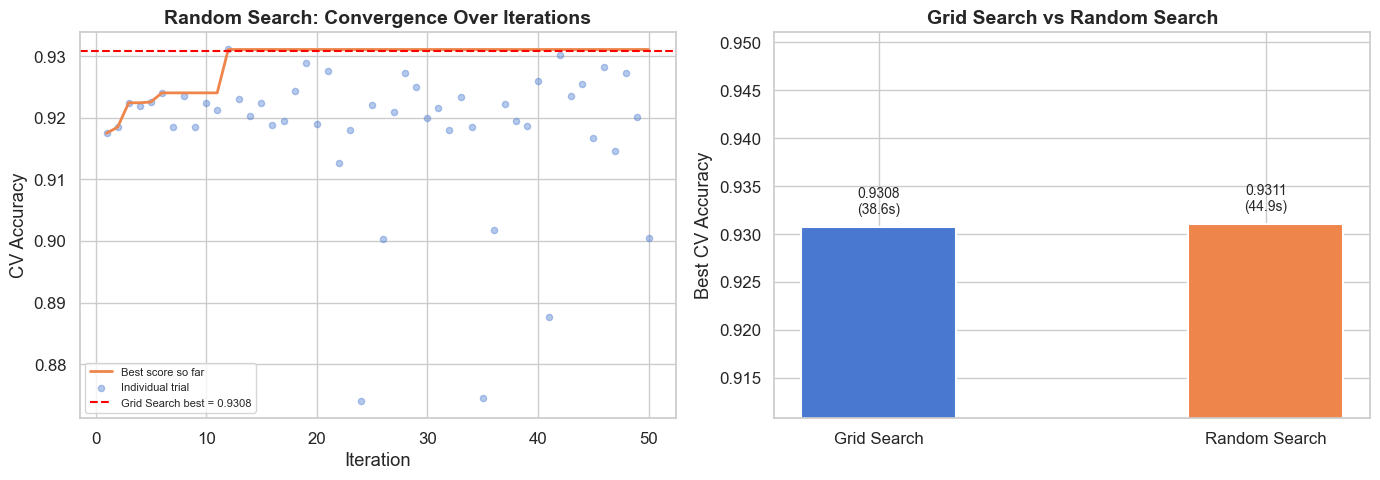

Grid Search    →  Best: 93.08%  |  Time: 38.6s  |  Fits: 270
Random Search  →  Best: 93.11%  |  Time: 44.9s  |  Fits: 250


In [43]:
# Visualize Random Search results
random_results = pd.DataFrame(random_search.cv_results_)
random_scores_all = random_results['mean_test_score'].values
best_so_far_rand  = np.maximum.accumulate(random_scores_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence curve
axes[0].plot(range(1, N_ITER + 1), best_so_far_rand, linewidth=2,
             color=sns.color_palette('muted')[1], label='Best score so far')
axes[0].scatter(range(1, N_ITER + 1), random_scores_all, alpha=0.4,
                color=sns.color_palette('muted')[0], s=20, label='Individual trial')
axes[0].axhline(grid_search.best_score_, color='red', linestyle='--', linewidth=1.5,
                label=f'Grid Search best = {grid_search.best_score_:.4f}')
axes[0].set_title('Random Search: Convergence Over Iterations', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('CV Accuracy')
axes[0].legend(fontsize=8)

# Grid vs Random
methods = ['Grid Search', 'Random Search']
scores  = [grid_search.best_score_, random_search.best_score_]
times   = [grid_time, random_time]
bars = axes[1].bar(methods, scores, color=sns.color_palette('muted', 2),
                   edgecolor='white', linewidth=1.5, width=0.4)
axes[1].set_ylim(min(scores) - 0.02, max(scores) + 0.02)
axes[1].set_title('Grid Search vs Random Search', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Best CV Accuracy')
for bar, score, t in zip(bars, scores, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}\n({t:.1f}s)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
print(f'Grid Search    →  Best: {grid_search.best_score_*100:.2f}%  |  Time: {grid_time:.1f}s  |  Fits: {total_combinations*5}')
print(f'Random Search  →  Best: {random_search.best_score_*100:.2f}%  |  Time: {random_time:.1f}s  |  Fits: {N_ITER*5}')

### Reading These Charts

**Left chart — Convergence Curve:**
The **solid line** tracks the best score found *so far* as trials accumulate. It can only ever go up or stay flat — once a good combination is found, it stays the best. The **scattered dots** are the score of each individual trial. The **red dashed line** is Grid Search's best for reference. If Random Search's convergence line reaches or exceeds the Grid Search line with fewer iterations, Random Search found an equally good solution more efficiently.

**Right chart — Grid Search vs Random Search:**
A direct comparison of the best score each method achieved, with the time taken shown below each bar. This highlights the efficiency trade-off: did Random Search get a similar accuracy score in less time?

---
# Section 7 — Bayesian Optimization

### The Limitation of Random Search
Random Search is better than Grid Search, but it's still **unintelligent** — it has no memory. Each trial is completely independent of all previous trials. It doesn't learn from experience.

### How Bayesian Optimization Works
Bayesian Optimization treats hyperparameter tuning as an **optimization problem under uncertainty**. After every trial, it builds a probabilistic **surrogate model** that approximates the relationship between hyperparameter values and model performance.

It then uses an **acquisition function** to decide where to sample next — intelligently balancing:
- **Exploitation:** Search near regions that performed well
- **Exploration:** Try unexplored regions that might be even better

```
Trial 1:  Random starting point                    → Score: 0.91
Trial 2:  Random starting point                    → Score: 0.89
Trial 3:  Surrogate model says "try here"          → Score: 0.93  ← promising!
Trial 4:  Exploit region near trial 3              → Score: 0.94
Trial 5:  Explore a different uncertain region     → Score: 0.90
Trial 6:  Exploit further around trial 4           → Score: 0.95  ← best so far!
...
```

### Two Libraries, Two Approaches
We'll demonstrate Bayesian Optimization using two different libraries that take different algorithmic approaches:

| Library | Surrogate Model | API Style | Best For |
|---------|----------------|-----------|----------|
| **scikit-optimize** | Gaussian Process (GP) | Drop-in sklearn replacement | Familiarity, small search spaces |
| **Optuna** | Tree-structured Parzen Estimator (TPE) | Objective function pattern | Production, large spaces, speed |

---

## Section 7a — Bayesian Optimization with scikit-optimize (`BayesSearchCV`)

### About scikit-optimize
`scikit-optimize` (also called `skopt`) provides `BayesSearchCV` — a **direct drop-in replacement** for `GridSearchCV` and `RandomizedSearchCV`. If you already know how to use sklearn's search CV objects, you know how to use this.

### The Surrogate Model: Gaussian Process
Under the hood, `skopt` fits a **Gaussian Process (GP)** regression model to the results seen so far. A GP doesn't just predict a score — it predicts a score *and* its uncertainty. This uncertainty is what drives the exploration vs exploitation balance.

- High predicted score + low uncertainty → **exploit** (we're confident it's good)
- Low predicted score + high uncertainty → **explore** (we don't know, worth checking)

### Key Advantage
The `BayesSearchCV` API accepts sklearn-style search spaces (`Integer`, `Real`, `Categorical`) and integrates seamlessly with sklearn pipelines and scoring.

### Known Limitation
Gaussian Processes scale poorly with the number of observations — they become slow when you have many trials (100+). This is one reason Optuna's TPE approach is often preferred at scale.

In [44]:
# ── Bayesian Optimization: scikit-optimize (BayesSearchCV) ────────────────────
skopt_space = {
    'n_estimators'     : Integer(50, 300),
    'max_depth'        : Integer(5, 30),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf' : Integer(1, 10),
    'max_features'     : Categorical(['sqrt', 'log2'])
}

N_SKOPT = 50
print(f'skopt BayesSearchCV: {N_SKOPT} trials × 5 folds = {N_SKOPT*5} model fits')
print('Running... (this may take a minute)')

# on_step callback — called after each trial to show a tidy progress line
trial_counter = [0]
def on_step(result):
    trial_counter[0] += 1
    best_so_far = max(result.func_vals) * -1  # skopt minimises, so negate
    print(f'  Trial {trial_counter[0]:>2}/{N_SKOPT}  |  '
          f'This trial: {result.func_vals[-1]*-1:.4f}  |  '
          f'Best so far: {best_so_far:.4f}', flush=True)

bayes_skopt = BayesSearchCV(
    estimator     = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    search_spaces = skopt_space,
    n_iter        = N_SKOPT,
    cv            = cv_tune,
    scoring       = 'accuracy',
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
    verbose       = 0
)

start = time.time()
bayes_skopt.fit(X_sample, y_sample, callback=on_step)
skopt_time = time.time() - start

skopt_best_score  = bayes_skopt.best_score_
skopt_best_params = bayes_skopt.best_params_

print(f'\n── skopt BayesSearchCV Results ──────────────────────────')
print(f'  Completed in    : {skopt_time:.1f} seconds')
print(f'  Total fits      : {N_SKOPT} trials × 5 folds = {N_SKOPT*5}')
print(f'  Best CV Accuracy: {skopt_best_score:.4f} ({skopt_best_score*100:.2f}%)')
print(f'  Best Parameters : {dict(skopt_best_params)}')

skopt BayesSearchCV: 50 trials × 5 folds = 250 model fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fit

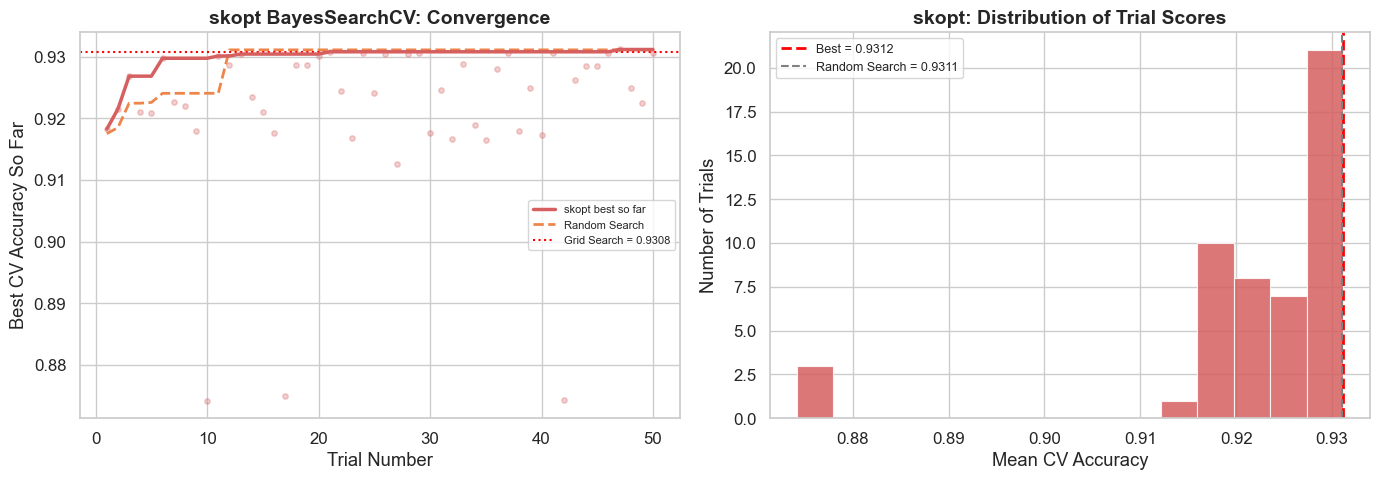

skopt BayesSearchCV  →  Best: 93.12%  |  Time: 91.0s  |  Fits: 250


In [45]:
# Visualize skopt results
skopt_results     = pd.DataFrame(bayes_skopt.cv_results_)
skopt_scores_all  = skopt_results['mean_test_score'].values
best_so_far_skopt = np.maximum.accumulate(skopt_scores_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence curve
axes[0].plot(range(1, N_SKOPT + 1), best_so_far_skopt, linewidth=2.5,
             color=sns.color_palette('muted')[3], label='skopt best so far', zorder=3)
axes[0].plot(range(1, N_ITER + 1), best_so_far_rand, linewidth=2,
             color=sns.color_palette('muted')[1], linestyle='--', label='Random Search', zorder=2)
axes[0].scatter(range(1, N_SKOPT + 1), skopt_scores_all, alpha=0.3,
                color=sns.color_palette('muted')[3], s=15, zorder=1)
axes[0].axhline(grid_search.best_score_, color='red', linestyle=':', linewidth=1.5,
                label=f'Grid Search = {grid_search.best_score_:.4f}')
axes[0].set_title('skopt BayesSearchCV: Convergence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Best CV Accuracy So Far')
axes[0].legend(fontsize=8)

# Score distribution across all skopt trials
axes[1].hist(skopt_scores_all, bins=15,
             color=sns.color_palette('muted')[3], edgecolor='white', linewidth=0.8, alpha=0.85)
axes[1].axvline(skopt_best_score, color='red', linestyle='--', linewidth=2,
                label=f'Best = {skopt_best_score:.4f}')
axes[1].axvline(random_search.best_score_, color='grey', linestyle='--', linewidth=1.5,
                label=f'Random Search = {random_search.best_score_:.4f}')
axes[1].set_title('skopt: Distribution of Trial Scores', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean CV Accuracy')
axes[1].set_ylabel('Number of Trials')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'skopt BayesSearchCV  →  Best: {skopt_best_score*100:.2f}%  |  Time: {skopt_time:.1f}s  |  Fits: {N_SKOPT*5}')

### Reading These Charts

**Left chart — skopt Convergence:**
The **solid coloured line** is skopt's best-so-far curve. The **dashed line** is Random Search's best-so-far for comparison. The **dotted red line** is Grid Search's best. If skopt's line rises faster and earlier than Random Search's line, the Gaussian Process surrogate is doing its job — it is using what it learned from past trials to pick better candidates sooner.

**Right chart — Distribution of skopt Trial Scores:**
Shows the spread of all individual trial scores. The **red line** is skopt's best; the **grey line** is Random Search's best. If skopt's trials are clustered at higher scores compared to Random Search, the surrogate model is steering the search towards better regions of the hyperparameter space rather than sampling randomly.

---
## Section 7b — Bayesian Optimization with Optuna (TPE)

### About Optuna
[Optuna](https://optuna.org) is the **industry-standard** Bayesian optimization framework. It is actively maintained, widely used at ML companies and in Kaggle competitions, and supports advanced features like pruning (early stopping of bad trials) and parallel optimization.

### The Surrogate Model: TPE (Tree-structured Parzen Estimator)

Instead of a Gaussian Process, Optuna uses **TPE** — a fundamentally different approach to deciding which hyperparameters to try next.

#### How TPE Works

After running several trials, TPE splits all the results into two groups:
- **Good trials** — the top performing runs (e.g. top 25%)
- **Bad trials** — everything else

Then it asks one question for each hyperparameter:
> *"What values appeared more often in the good trials than in the bad trials?"

It then **proposes values that are more likely to come from the good group** than the bad group.

#### A Simple Example

Say we have run 10 trials tuning `max_depth` and we split them:

```
Good trials (top 25%):  max_depth = [18, 20, 19, 22]   ← clustered around 18–22
Bad trials  (rest):     max_depth = [5, 8, 30, 6, 28, 7]  ← spread out at extremes
```

TPE fits a probability curve to each group:

```
Good group distribution:  peaks around 18–22
Bad group distribution:   spread across 5–30
```

For the next trial, TPE picks a value where `P(value | good) / P(value | bad)` is highest — in this case something around **20**, because that value is far more likely from the good group than the bad group.

#### Why "Tree-structured"?

The "tree-structured" part refers to how TPE handles **conditional hyperparameters** — situations where one hyperparameter only makes sense if another has a certain value (e.g. tuning `max_leaf_nodes` only when `max_depth` is unconstrained). TPE models these dependencies as a tree. For our Random Forest example this doesn't come into play, but it's why the algorithm generalises well to complex search spaces.

In practice, **TPE scales better** than GP for high-dimensional hyperparameter spaces and handles categorical parameters more naturally.

### The API: Objective Function Pattern
Optuna uses a different API than sklearn — you define an `objective` function that:
1. Receives a `trial` object
2. Uses the trial to **suggest** hyperparameter values
3. Trains and evaluates the model
4. Returns the score

This is more flexible than `BayesSearchCV` — you can put any logic inside the objective, including custom preprocessing, multiple models, or conditional hyperparameters.

### skopt vs Optuna — Quick Summary

| | scikit-optimize | Optuna |
|---|---|---|
| Surrogate | Gaussian Process | TPE |
| API | Drop-in sklearn | Objective function |
| Scalability | Slower at 100+ trials | Handles 1000s of trials |
| Maintenance | Minimal (last release 2021) | Actively maintained |
| Industry use | Declining | Growing — current standard |

In [46]:
# ── Bayesian Optimization: Optuna (TPE) ───────────────────────────────────────
def objective(trial):
    """Optuna objective — called once per trial."""
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators',      50,  300),
        'max_depth'        : trial.suggest_int('max_depth',          5,   30),
        'min_samples_split': trial.suggest_int('min_samples_split',  2,   20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf',   1,   10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model  = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    scores = cross_val_score(model, X_sample, y_sample,
                             cv=cv_tune, scoring='accuracy', n_jobs=-1)
    return scores.mean()

N_TRIALS = 50
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

print(f'Optuna TPE: {N_TRIALS} trials × 5 folds = {N_TRIALS*5} model fits')
start = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
optuna_time = time.time() - start

optuna_best_score  = study.best_value
optuna_best_params = study.best_params

print(f'\nCompleted in      : {optuna_time:.1f} seconds')
print(f'Best CV Accuracy  : {optuna_best_score:.4f} ({optuna_best_score*100:.2f}%)')
print(f'Best Parameters   : {optuna_best_params}')

Optuna TPE: 50 trials × 5 folds = 250 model fits


Best trial: 45. Best value: 0.93054: 100%|██████████| 50/50 [01:06<00:00,  1.33s/it] 


Completed in      : 66.3 seconds
Best CV Accuracy  : 0.9305 (93.05%)
Best Parameters   : {'n_estimators': 195, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}


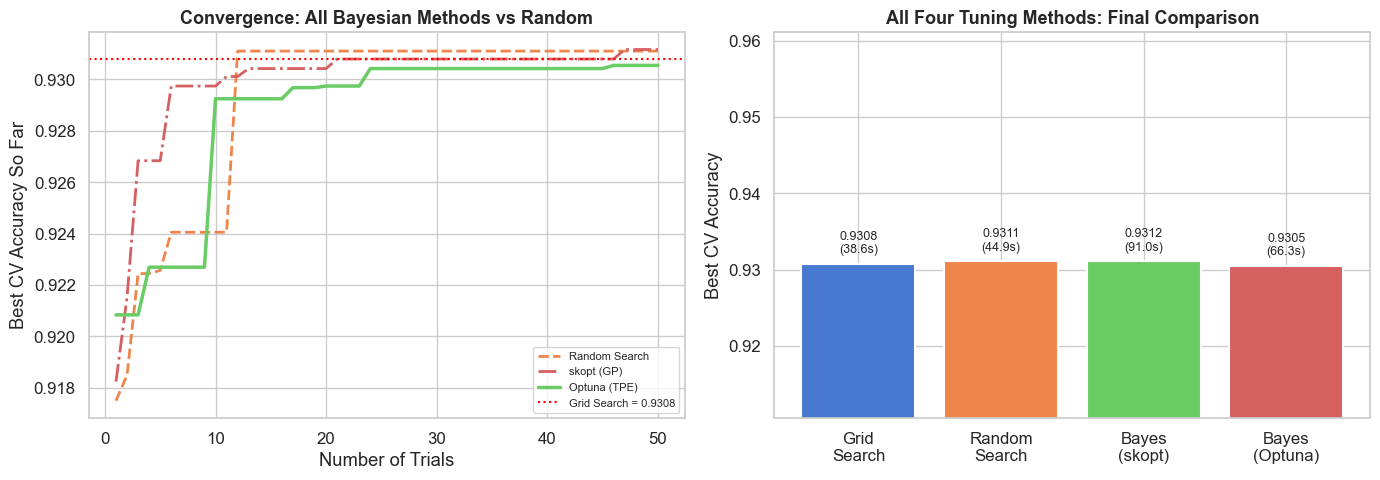


── Tier 2 Final Comparison ─────────────────────────────────────────
  Grid Search         →  93.08%  |  38.6s  |  270 fits
  Random Search       →  93.11%  |  44.9s  |  250 fits
  Bayesian (skopt)    →  93.12%  |  91.0s  |  250 fits
  Bayesian (Optuna)   →  93.05%  |  66.3s  |  250 fits


In [47]:
# Visualize Optuna results and compare all four methods
optuna_scores_all  = [t.value for t in study.trials]
best_so_far_optuna = np.maximum.accumulate(optuna_scores_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence: all four methods overlaid
n = min(N_ITER, N_SKOPT, N_TRIALS)  # align x-axis to shortest run
axes[0].plot(range(1, n + 1), best_so_far_rand[:n],   linewidth=2, linestyle='--',
             color=sns.color_palette('muted')[1], label='Random Search')
axes[0].plot(range(1, n + 1), best_so_far_skopt[:n],  linewidth=2, linestyle='-.',
             color=sns.color_palette('muted')[3], label='skopt (GP)')
axes[0].plot(range(1, n + 1), best_so_far_optuna[:n], linewidth=2.5, linestyle='-',
             color=sns.color_palette('muted')[2], label='Optuna (TPE)')
axes[0].axhline(grid_search.best_score_, color='red', linestyle=':', linewidth=1.5,
                label=f'Grid Search = {grid_search.best_score_:.4f}')
axes[0].set_title('Convergence: All Bayesian Methods vs Random', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Trials')
axes[0].set_ylabel('Best CV Accuracy So Far')
axes[0].legend(fontsize=8)

# Final bar chart: all four methods
all_methods = ['Grid\nSearch', 'Random\nSearch', 'Bayes\n(skopt)', 'Bayes\n(Optuna)']
all_scores  = [grid_search.best_score_, random_search.best_score_,
               skopt_best_score, optuna_best_score]
all_times   = [grid_time, random_time, skopt_time, optuna_time]
all_colors  = sns.color_palette('muted', 4)

bars = axes[1].bar(all_methods, all_scores, color=all_colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(min(all_scores) - 0.02, max(all_scores) + 0.03)
axes[1].set_title('All Four Tuning Methods: Final Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Best CV Accuracy')
for bar, score, t in zip(bars, all_scores, all_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}\n({t:.1f}s)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n── Tier 2 Final Comparison ─────────────────────────────────────────')
print(f'  Grid Search         →  {grid_search.best_score_*100:.2f}%  |  {grid_time:.1f}s  |  {total_combinations*5} fits')
print(f'  Random Search       →  {random_search.best_score_*100:.2f}%  |  {random_time:.1f}s  |  {N_ITER*5} fits')
print(f'  Bayesian (skopt)    →  {skopt_best_score*100:.2f}%  |  {skopt_time:.1f}s  |  {N_SKOPT*5} fits')
print(f'  Bayesian (Optuna)   →  {optuna_best_score*100:.2f}%  |  {optuna_time:.1f}s  |  {N_TRIALS*5} fits')

### Reading These Charts

**Left chart — Convergence of All Bayesian Methods vs Random:**
All three methods (Random Search, skopt, Optuna) are overlaid so you can compare how quickly each one finds a good solution. The **dotted red line** is Grid Search's best for a baseline. A method whose line rises steeply early and then plateaus is being very efficient — it found a good region quickly and then refined within it. A method whose line rises slowly or erratically is either struggling to learn from past trials or is exploring too much.

**Right chart — Final Best Score for All Four Methods:**
The ultimate apples-to-apples comparison. All four methods were given the same data and the same number of model fits (50 trials × 5 folds each). The bar height is the best accuracy found; the label shows the time taken. The ideal method achieves the **highest accuracy in the shortest time**.

---
# Final Summary
---

## Putting It All Together

Let's consolidate everything we've covered in this notebook into a single comparison view.

In [48]:
# ── Complete Summary Table ────────────────────────────────────────────────────
summary = {
    'Technique'    : ['Train/Test Split', 'K-Fold CV', 'Stratified K-Fold',
                      'Time Series Split', 'Grid Search CV',
                      'Random Search CV', 'Bayesian (skopt)', 'Bayesian (Optuna)'],
    'Tier'         : ['Tier 1'] * 4 + ['Tier 2'] * 4,
    'Mean Accuracy': [
        tt_accuracy,
        kfold_scores.mean(),
        skfold_scores.mean(),
        ts_scores.mean(),
        grid_search.best_score_,
        random_search.best_score_,
        skopt_best_score,
        optuna_best_score
    ],
    'Std Dev'      : [
        None,
        kfold_scores.std(),
        skfold_scores.std(),
        ts_scores.std(),
        None, None, None, None
    ]
}

summary_df = pd.DataFrame(summary)
summary_df['Accuracy (%)'] = summary_df['Mean Accuracy'].apply(lambda x: f'{x*100:.2f}%')
summary_df['Std Dev (%)']  = summary_df['Std Dev'].apply(
    lambda x: f'± {x*100:.2f}%' if x is not None else '—'
)

print('=' * 70)
print('COMPLETE CROSS-VALIDATION SUMMARY')
print('=' * 70)
print(summary_df[['Technique', 'Tier', 'Accuracy (%)', 'Std Dev (%)']].to_string(index=False))
print('=' * 70)

COMPLETE CROSS-VALIDATION SUMMARY
        Technique   Tier Accuracy (%) Std Dev (%)
 Train/Test Split Tier 1       94.81%      ± nan%
        K-Fold CV Tier 1       94.46%     ± 0.28%
Stratified K-Fold Tier 1       94.50%     ± 0.25%
Time Series Split Tier 1       60.50%    ± 33.95%
   Grid Search CV Tier 2       93.08%      ± nan%
 Random Search CV Tier 2       93.11%      ± nan%
 Bayesian (skopt) Tier 2       93.12%      ± nan%
Bayesian (Optuna) Tier 2       93.05%      ± nan%


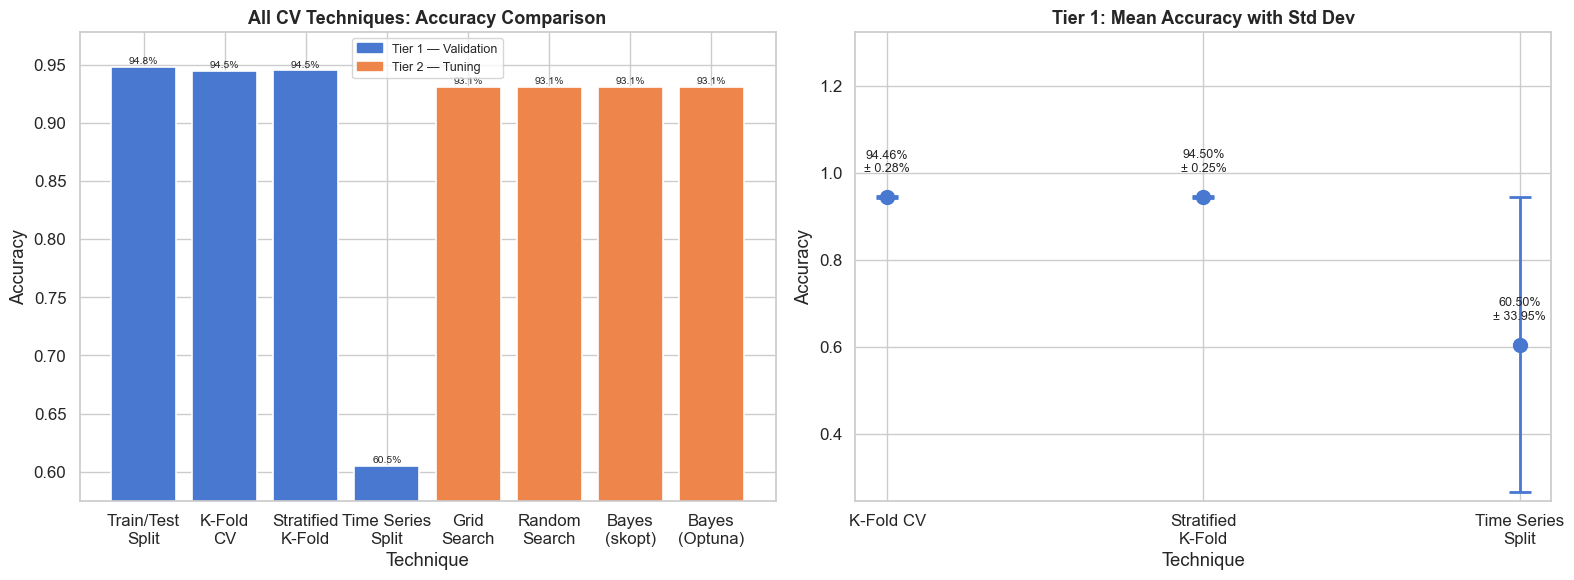

In [49]:
# Final visualization: complete comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy bar chart — all 8 techniques
technique_labels = ['Train/Test\nSplit', 'K-Fold\nCV', 'Stratified\nK-Fold',
                    'Time Series\nSplit', 'Grid\nSearch', 'Random\nSearch',
                    'Bayes\n(skopt)', 'Bayes\n(Optuna)']
accuracies  = summary['Mean Accuracy']
tier_colors = [sns.color_palette('muted')[0]] * 4 + [sns.color_palette('muted')[1]] * 4

bars = axes[0].bar(technique_labels, accuracies, color=tier_colors,
                   edgecolor='white', linewidth=1.2)
axes[0].set_ylim(min(accuracies) - 0.03, max(accuracies) + 0.03)
axes[0].set_title('All CV Techniques: Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Technique')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=7.5)
tier1_patch = mpatches.Patch(color=sns.color_palette('muted')[0], label='Tier 1 — Validation')
tier2_patch = mpatches.Patch(color=sns.color_palette('muted')[1], label='Tier 2 — Tuning')
axes[0].legend(handles=[tier1_patch, tier2_patch], fontsize=9)

# Std dev error bars — Tier 1 CV methods
tier1_methods = ['K-Fold CV', 'Stratified\nK-Fold', 'Time Series\nSplit']
tier1_means   = [kfold_scores.mean(), skfold_scores.mean(), ts_scores.mean()]
tier1_stds    = [kfold_scores.std(),  skfold_scores.std(),  ts_scores.std()]

axes[1].errorbar(tier1_methods, tier1_means, yerr=tier1_stds,
                 fmt='o', capsize=8, capthick=2, markersize=10,
                 color=sns.color_palette('muted')[0], linewidth=2, elinewidth=2)
for method, mean, std in zip(tier1_methods, tier1_means, tier1_stds):
    axes[1].annotate(f'{mean*100:.2f}%\n± {std*100:.2f}%',
                     xy=(method, mean), xytext=(0, 18),
                     textcoords='offset points', ha='center', fontsize=9)
axes[1].set_title('Tier 1: Mean Accuracy with Std Dev', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Technique')
y_min = min(tier1_means) - max(tier1_stds) - 0.02
y_max = max(tier1_means) + max(tier1_stds) + 0.04
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

### Reading These Charts

**Left chart — All 8 Techniques: Accuracy Comparison:**
Blue bars are Tier 1 (validation methods); orange bars are Tier 2 (tuning methods). Note that Tier 1 and Tier 2 scores are **not directly comparable** — Tier 1 methods run on the full 54k dataset with default hyperparameters, while Tier 2 methods run on a 30% sample and are searching for the best hyperparameters. The Time Series Split score stands out as much lower — this is because we sorted diamonds by price to simulate temporal order, so each split sees a very different price range in the test set compared to what it trained on.

**Right chart — Tier 1: Mean Accuracy with Standard Deviation:**
The dots show the mean accuracy for each Tier 1 multi-fold method, and the vertical lines (error bars) show ±1 standard deviation across the folds. A **short error bar** means the model's score barely changes from fold to fold — it is stable and reliable. A **long error bar** means the score varies a lot depending on which data the model trains on — less trustworthy. This is one of the most important charts in the notebook: accuracy alone is not enough; stability matters too.

---
## Key Takeaways

### Tier 1 — Validation Fundamentals

| Technique | When to Use |
|-----------|-------------|
| **Train/Test Split** | Quick sanity check, large datasets, starting point for any project |
| **K-Fold CV** | General-purpose evaluation when data is shuffleable and classes are balanced |
| **Stratified K-Fold** | Classification problems, especially with imbalanced class distributions |
| **Time Series Split** | Any data with a temporal order — financial data, sensor readings, forecasting |

### Tier 2 — Hyperparameter Tuning

| Technique | When to Use |
|-----------|-------------|
| **Grid Search CV** | Small parameter spaces (≤ 3 params), exhaustive coverage needed |
| **Random Search CV** | Medium-large parameter spaces, limited compute budget |
| **Bayesian (skopt)** | Familiar sklearn-style API, moderate search spaces |
| **Bayesian (Optuna)** | Large search spaces, expensive models, production tuning |

### The Golden Rules

1. **Never evaluate on training data.** A model that memorizes training data is useless in production.
2. **Use Stratified K-Fold by default** for classification — it's almost always better than plain K-Fold.
3. **Respect time order** in temporal data — shuffling time series data is a form of data leakage.
4. **Standard deviation matters** as much as mean accuracy — a stable model is more trustworthy than a lucky one.
5. **Bayesian > Random > Grid** in terms of search efficiency, but all are valid depending on context.
6. **Optuna is the current industry standard** for Bayesian optimization — learn the objective function pattern.
7. **The best tuning method is the one that fits your compute budget** — a well-run Random Search often beats a poorly-configured Bayesian search.

---

*Built with the Diamonds dataset from Seaborn · Random Forest Classifier · scikit-learn · scikit-optimize · Optuna*